# Fingertip force estimator - exploration and test-set evaluation

Reads `Model/checkpoints/metrics_history.csv` (written every epoch by `train.py`) and `Model/checkpoints/best_model.pt` (the checkpoint with the best validation MAE), then evaluates that checkpoint on the held-out test session. Run this after `mainModel.py` has finished a training run.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import dataset
import model as model_module
import train as train_module

config = dataset.load_config()
model_config = config["model_training"]
checkpoint_dir = os.path.join(dataset.REPO_ROOT, model_config["training"]["checkpoint_dir"])
metrics_path = os.path.join(checkpoint_dir, model_config["training"]["metrics_history_file"])
checkpoint_path = os.path.join(checkpoint_dir, "best_model.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"checkpoint_dir={checkpoint_dir}\ndevice={device}")

checkpoint_dir=/home/wouterdg/ForceEstimationPipeline/Model/checkpoints
device=cuda


## Training curves

Train/val Huber loss (normalized units) and validation MAE (newtons) over epochs.

Best epoch: 9  val_mae_n=2.238  val_r2=0.761


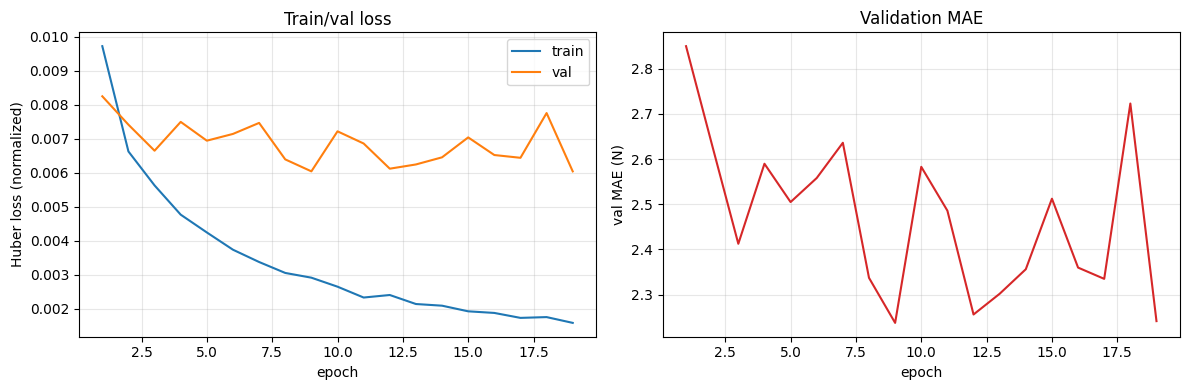

In [2]:
history = pd.read_csv(metrics_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["epoch"], history["train_loss"], label="train")
axes[0].plot(history["epoch"], history["val_loss"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("Huber loss (normalized)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Train/val loss")

axes[1].plot(history["epoch"], history["val_mae_n"], color="tab:red")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val MAE (N)"); axes[1].grid(alpha=0.3)
axes[1].set_title("Validation MAE")
fig.tight_layout()

best_epoch = history.loc[history["val_mae_n"].idxmin()]
print(f"Best epoch: {int(best_epoch['epoch'])}  val_mae_n={best_epoch['val_mae_n']:.3f}  val_r2={best_epoch['val_r2']:.3f}")

## Load the best checkpoint

In [3]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
print("Checkpoint metadata:")
for key, value in checkpoint["metadata"].items():
    print(f"  {key}: {value}")

net = model_module.build_model(mean_normalized_label=0.0).to(device)
net.load_state_dict(checkpoint["model_state_dict"])
net.eval()

clamp_sign = checkpoint["metadata"]["prediction_clamp_sign"]
force_norm_scale_n = checkpoint["metadata"]["force_norm_scale_n"]
label_offset = checkpoint["metadata"]["label_frame_offset"]
autocast_dtype, _ = train_module.select_precision(device)
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, val_mae_n={checkpoint['val_mae_n']:.3f}")

Checkpoint metadata:
  window_length: 20
  temporal_stride_within_window: 1
  label_frame_offset: 10
  force_component: Fz
  force_filter_cutoff_hz: 12.0
  force_filter_order: 4
  crop_size_px: 112
  crop_physical_size_mm: None
  rgb_mean: [0.43215999007225037, 0.39466598629951477, 0.3764500021934509]
  rgb_std: [0.2280299961566925, 0.22145000100135803, 0.21698899567127228]
  depth_reference_definition: median of the originally-valid depth pixels (mm) at the window's label (centre) frame, subtracted from every frame in the window
  depth_clip_mm: 40.0
  depth_sign_convention: positive = farther from camera than the window reference, negative = closer
  force_norm_scale_n: 20.0
  prediction_clamp_sign: -1.0
Loaded checkpoint from epoch 9, val_mae_n=2.238


## Sample clips (sanity check)

De-normalized color frames from a few training-split windows (augmentation on), at the window's start/label/end frames, with the true label. Confirms color order, crop placement, and that a geometric augmentation (if it fired) looks consistent across frames rather than jittering per frame.

[dataset] Loading train split: 12 session(s)
  [dataset] session_20260924_140635: 2171 frames, 16.4% originally-invalid depth pixels (hole-filled)
  [dataset] session_20260924_142230: 2194 frames, 15.8% originally-invalid depth pixels (hole-filled)
  [dataset] session_20260924_142929: 2742 frames, 15.9% originally-invalid depth pixels (hole-filled)
  [dataset] session_20260924_143501: 2783 frames, 16.9% originally-invalid depth pixels (hole-filled)
  [dataset] session_20260924_145719: 3266 frames, 16.4% originally-invalid depth pixels (hole-filled)
  [dataset] session_20260924_150401: 2609 frames, 16.6% originally-invalid depth pixels (hole-filled)
  [dataset] session_20260924_152908: 2971 frames, 14.5% originally-invalid depth pixels (hole-filled)
  [dataset] session_20260924_153324: 2308 frames, 14.7% originally-invalid depth pixels (hole-filled)
  [dataset] session_20260925_111917: 2202 frames, 17.0% originally-invalid depth pixels (hole-filled)
  [dataset] session_20260925_112200: 

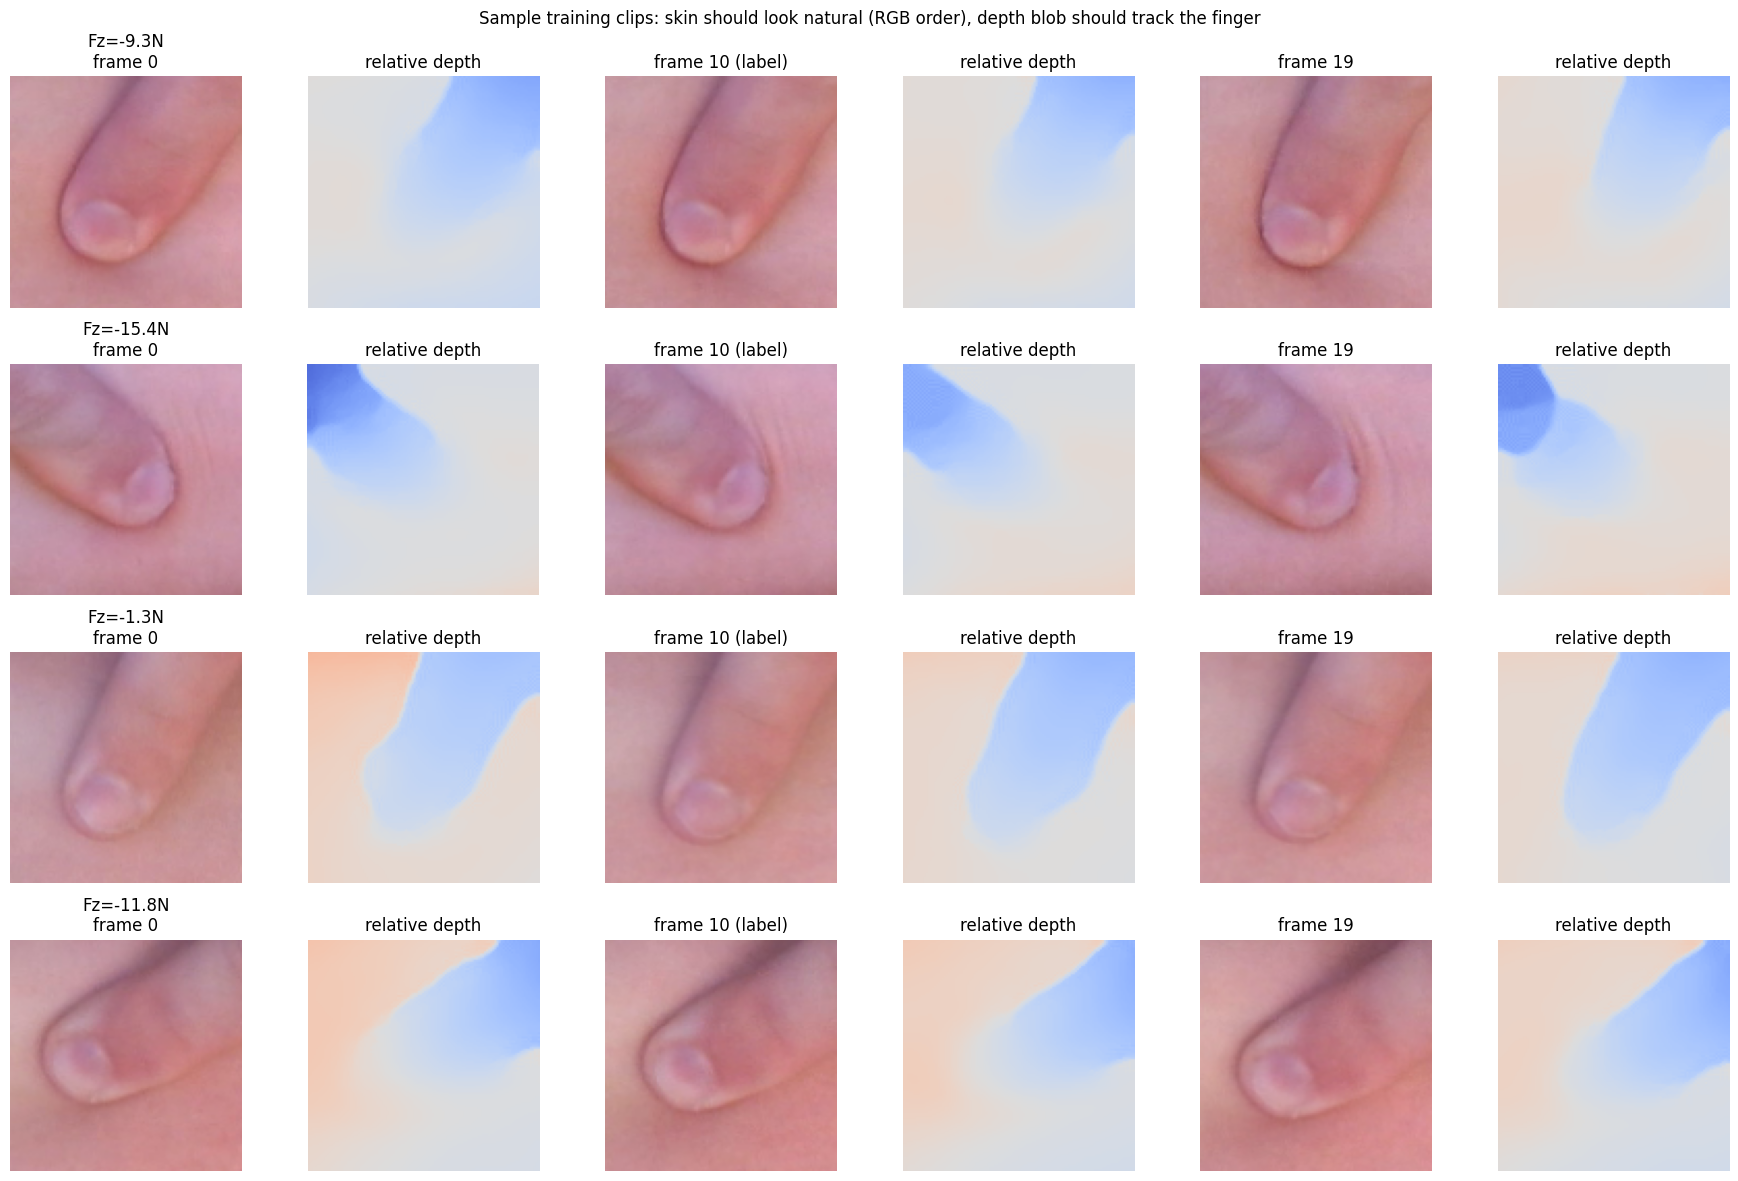

In [4]:
train_dataset = dataset.build_dataset("train", config)

num_samples = 4
shown_offsets = [0, label_offset, train_dataset.window_length - 1]
fig, axes = plt.subplots(num_samples, len(shown_offsets) * 2, figsize=(3 * len(shown_offsets) * 2, 3 * num_samples))
sample_indices = np.linspace(0, len(train_dataset) - 1, num_samples, dtype=int)
for row, sample_index in enumerate(sample_indices):
    item = train_dataset[int(sample_index)]
    clip = item["clip"]
    label_n = item["label_n"].item()
    for col, offset in enumerate(shown_offsets):
        color_frame = clip[:3, offset].permute(1, 2, 0).numpy() * dataset.RGB_STD + dataset.RGB_MEAN
        depth_frame = clip[3, offset].numpy()
        ax_color = axes[row, col * 2]
        ax_color.imshow(np.clip(color_frame, 0, 1))
        title = f"frame {offset}" + (" (label)" if offset == label_offset else "")
        if col == 0:
            title = f"Fz={label_n:.1f}N\n{title}"
        ax_color.set_title(title); ax_color.axis("off")
        ax_depth = axes[row, col * 2 + 1]
        ax_depth.imshow(depth_frame, cmap="coolwarm", vmin=-1, vmax=1)
        ax_depth.set_title("relative depth"); ax_depth.axis("off")
fig.suptitle("Sample training clips: skin should look natural (RGB order), depth blob should track the finger")
fig.tight_layout()

## Test-set evaluation

MAE, RMSE, R² in newtons on the held-out test session, evaluated densely (eval_stride=1).

In [5]:
test_dataset, test_loader = dataset.build_dataloader("test", config, shuffle=False)
loss_fn = torch.nn.HuberLoss(delta=model_config["training"]["loss"]["huber_delta_n"] / force_norm_scale_n)
test_loss, test_mae_n, test_rmse_n, test_r2 = train_module.run_validation(
    net, test_loader, device, autocast_dtype, loss_fn, force_norm_scale_n, clamp_sign)
print(f"Test set ({len(test_dataset)} windows): MAE={test_mae_n:.3f} N  RMSE={test_rmse_n:.3f} N  R2={test_r2:.3f}")

[dataset] Loading test split: 3 session(s)
  [dataset] session_20260924_145118: 3412 frames, 16.8% originally-invalid depth pixels (hole-filled)
  [dataset] session_20260924_153632: 1955 frames, 15.1% originally-invalid depth pixels (hole-filled)
  [dataset] session_20260925_115002: 2226 frames, 17.9% originally-invalid depth pixels (hole-filled)
  [dataset] test: 7536 candidate windows, 869 discarded (span > 0.8s), 1002 discarded (|dFz| > 5.0N), 5665 kept
Test set (5665 windows): MAE=2.814 N  RMSE=3.591 N  R2=0.637


## Predicted vs. true force (scatter)

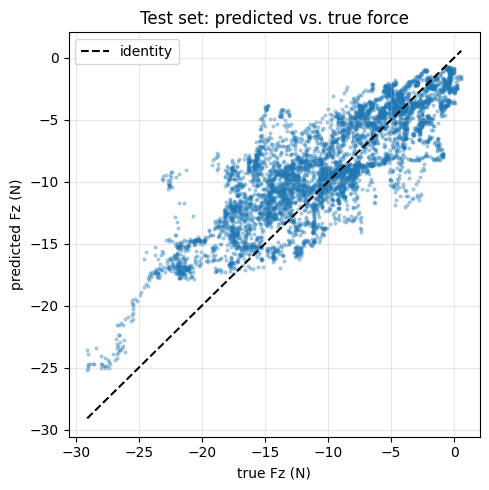

In [6]:
preds_n, trues_n, start_frames = [], [], []
net.eval()
with torch.inference_mode():
    for batch in test_loader:
        clip = batch["clip"].to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, dtype=autocast_dtype, enabled=autocast_dtype is not None):
            prediction = net(clip).squeeze(1).float()
        prediction = train_module._clamp_predictions(prediction, clamp_sign)
        preds_n.append(prediction.cpu().numpy() * force_norm_scale_n)
        trues_n.append(batch["label_n"].numpy())
        start_frames.append(batch["start_frame"].numpy())
preds_n = np.concatenate(preds_n)
trues_n = np.concatenate(trues_n)
start_frames = np.concatenate(start_frames)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(trues_n, preds_n, s=4, alpha=0.3)
lims = [min(trues_n.min(), preds_n.min()), max(trues_n.max(), preds_n.max())]
ax.plot(lims, lims, "k--", label="identity")
ax.set_xlabel("true Fz (N)"); ax.set_ylabel("predicted Fz (N)"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Test set: predicted vs. true force")
fig.tight_layout()

## Predicted vs. true force over time (full test trial)

The test split is one continuous session, evaluated at every frame (eval_stride=1), so this reconstructs a dense predicted-force curve over the whole trial - the view that matters for path planning, and where lag or noise becomes obvious.

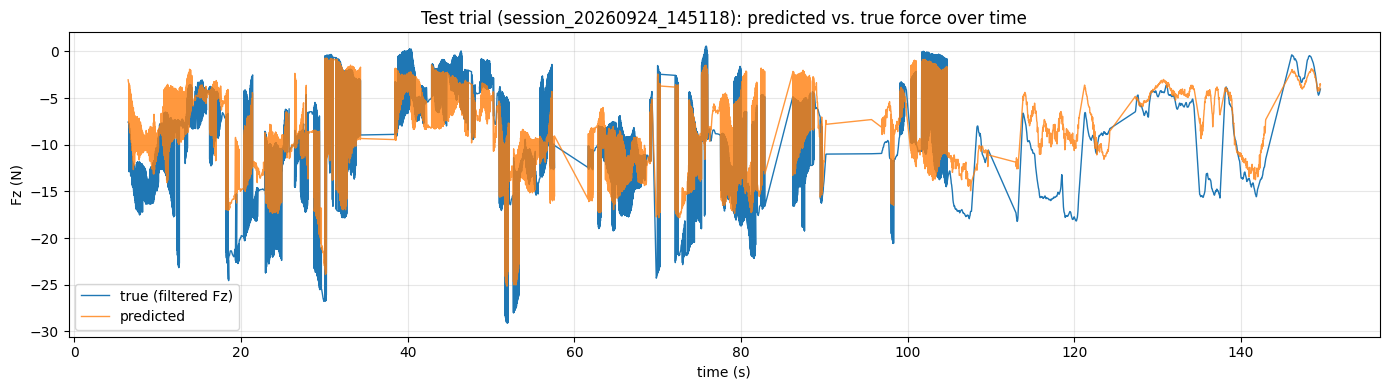

In [7]:
test_session = test_dataset.sessions[0]
label_frame_indices = start_frames + label_offset
elapsed_s = (test_session.frame_ts_ns[label_frame_indices] - test_session.frame_ts_ns[0]) / 1e9
order = np.argsort(elapsed_s)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(elapsed_s[order], trues_n[order], label="true (filtered Fz)", linewidth=1)
ax.plot(elapsed_s[order], preds_n[order], label="predicted", linewidth=1, alpha=0.8)
ax.set_xlabel("time (s)"); ax.set_ylabel("Fz (N)"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f"Test trial ({test_session.name}): predicted vs. true force over time")
fig.tight_layout()

## Error by force bin

MAE within each 2N true-force bin - shows whether the model regresses toward the mean and underestimates high forces.

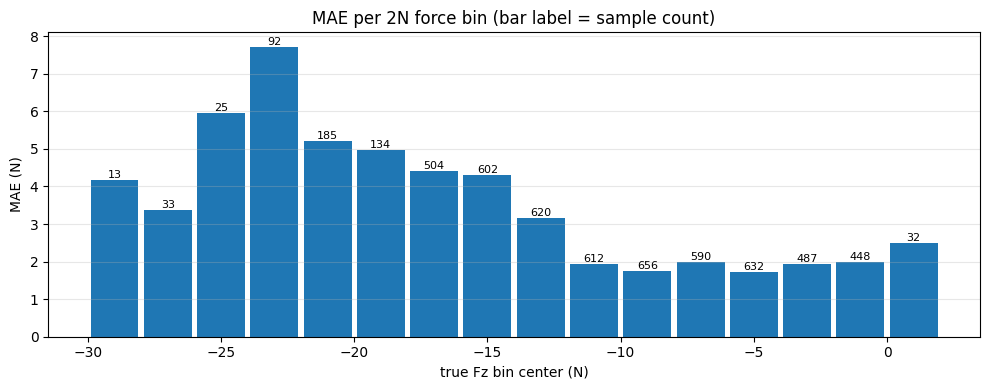

In [8]:
bin_width_n = 2.0
bin_edges = np.arange(np.floor(trues_n.min() / bin_width_n) * bin_width_n,
                       np.ceil(trues_n.max() / bin_width_n) * bin_width_n + bin_width_n, bin_width_n)
bin_index = np.digitize(trues_n, bin_edges)

bin_centers, bin_maes, bin_counts = [], [], []
for b in sorted(set(bin_index)):
    mask = bin_index == b
    if mask.sum() == 0:
        continue
    low = bin_edges[b - 1] if 0 < b <= len(bin_edges) else bin_edges[0]
    bin_centers.append(low + bin_width_n / 2)
    bin_maes.append(np.mean(np.abs(preds_n[mask] - trues_n[mask])))
    bin_counts.append(mask.sum())

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(bin_centers, bin_maes, width=bin_width_n * 0.9, color="tab:blue")
for bar, count in zip(bars, bin_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
            ha="center", va="bottom", fontsize=8)
ax.set_xlabel("true Fz bin center (N)"); ax.set_ylabel("MAE (N)")
ax.set_title("MAE per 2N force bin (bar label = sample count)")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()